# MOwNiT - lab 4 - Efekt Rungego - 01.04.2026

## Maksymilian Siemek & Hubert Kukla

### Zadanie 1

Funkcja przyjmująca wektor punktów z przedziału [-1, 1] i tworząca wykres z punktami x_j na osi odciętych i średnią geometryczną odległości do pozostałych punktów na osi rzędnych.

Najpierw generacja punktów Czebyszewa dla n = 5, 10, 20:

In [2]:
import numpy as np

def generate_chebyshev_points(n):

    k = np.arange(n) # liczby od 1 do n w tablicy zamiast for-a
    
    points = np.cos((2 * k + 1) / (2 * n) * np.pi)
    
    return points

chebyshev_vector_n5 = generate_chebyshev_points(5)
chebyshev_vector_n10 = generate_chebyshev_points(10)
chebyshev_vector_n20 = generate_chebyshev_points(20)
print(chebyshev_vector_n5)
print(chebyshev_vector_n10)
print(chebyshev_vector_n20)

[ 9.51056516e-01  5.87785252e-01  6.12323400e-17 -5.87785252e-01
 -9.51056516e-01]
[ 0.98768834  0.89100652  0.70710678  0.4539905   0.15643447 -0.15643447
 -0.4539905  -0.70710678 -0.89100652 -0.98768834]
[ 0.99691733  0.97236992  0.92387953  0.85264016  0.76040597  0.64944805
  0.52249856  0.38268343  0.23344536  0.0784591  -0.0784591  -0.23344536
 -0.38268343 -0.52249856 -0.64944805 -0.76040597 -0.85264016 -0.92387953
 -0.97236992 -0.99691733]


Teraz pora wygenerować punkty Legendre'a dla n = 5, 10, 20:

In [3]:
import numpy as np

def generate_legendre_points(n):

    factors = [0] * n + [1] # współczynniki wielomianu Legendre'a
    
    points = np.polynomial.legendre.legroots(factors)
    
    return points

legendre_vector_n5 = generate_legendre_points(5)
legendre_vector_n10 = generate_legendre_points(10)
legendre_vector_n20 = generate_legendre_points(20)
print(legendre_vector_n5)
print(legendre_vector_n10)
print(legendre_vector_n20)

[-9.06179846e-01 -5.38469310e-01 -2.88799790e-17  5.38469310e-01
  9.06179846e-01]
[-0.97390653 -0.86506337 -0.67940957 -0.43339539 -0.14887434  0.14887434
  0.43339539  0.67940957  0.86506337  0.97390653]
[-0.9931286  -0.96397193 -0.91223443 -0.83911697 -0.74633191 -0.63605368
 -0.510867   -0.37370609 -0.22778585 -0.07652652  0.07652652  0.22778585
  0.37370609  0.510867    0.63605368  0.74633191  0.83911697  0.91223443
  0.96397193  0.9931286 ]


Teraz generujemy równomiernie rozszerzone punkty dla n = 5, 10, 20:

In [4]:
import numpy as np

def generate_uniform_points(n):

    points = np.linspace(-1, 1, n)
    
    return points
    
uniform_vector_n5 = generate_uniform_points(5)
uniform_vector_n10 = generate_uniform_points(10)
uniform_vector_n20 = generate_uniform_points(20)
print(uniform_vector_n5)
print(uniform_vector_n10)
print(uniform_vector_n20)

[-1.  -0.5  0.   0.5  1. ]
[-1.         -0.77777778 -0.55555556 -0.33333333 -0.11111111  0.11111111
  0.33333333  0.55555556  0.77777778  1.        ]
[-1.         -0.89473684 -0.78947368 -0.68421053 -0.57894737 -0.47368421
 -0.36842105 -0.26315789 -0.15789474 -0.05263158  0.05263158  0.15789474
  0.26315789  0.36842105  0.47368421  0.57894737  0.68421053  0.78947368
  0.89473684  1.        ]


Na koniec definiujemy funkcję obliczającą współrzędne y dla punktów oraz rysującą wykres:

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_and_draw(points, name):

    N = len(points)
    y = np.zeros(N)
    
    for j in range(N):
        pozostale_punkty = np.delete(points, j)
        
        odleglosci = np.abs(points[j] - pozostale_punkty)
        
        iloczyn = np.prod(odleglosci)
        y[j] = iloczyn ** (1.0 / (N - 1))
        
    plt.plot(points, y, marker='o', linestyle='-', label=f"{name} (n={N})")

Teraz pozostało zlecić funkcji narysowanie wykresów dla wszystkich przypadków:

In [6]:
analyze_and_draw(chebyshev_vector_n5)

TypeError: analyze_and_draw() missing 1 required positional argument: 'name'

In [ ]:
analyze_and_draw(chebyshev_vector_n10)

In [ ]:
analyze_and_draw(chebyshev_vector_n20)

In [7]:
analyze_and_draw(legendre_vector_n5)

TypeError: analyze_and_draw() missing 1 required positional argument: 'name'

In [8]:
analyze_and_draw(legendre_vector_n10)

TypeError: analyze_and_draw() missing 1 required positional argument: 'name'

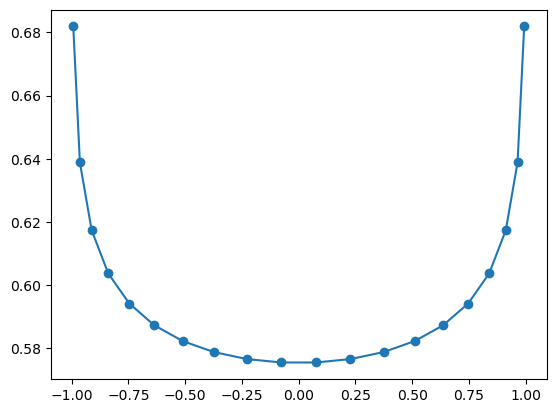

In [26]:
analyze_and_draw(legendre_vector_n20)

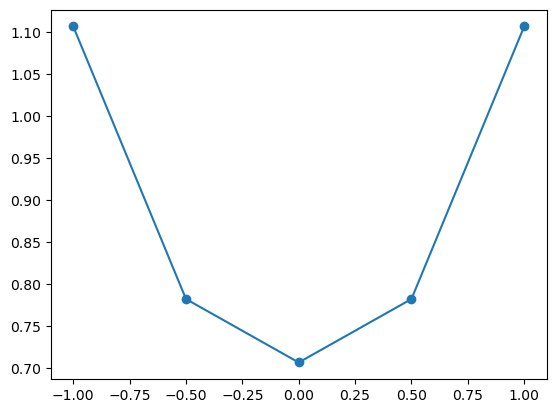

In [27]:
analyze_and_draw(uniform_vector_n5)

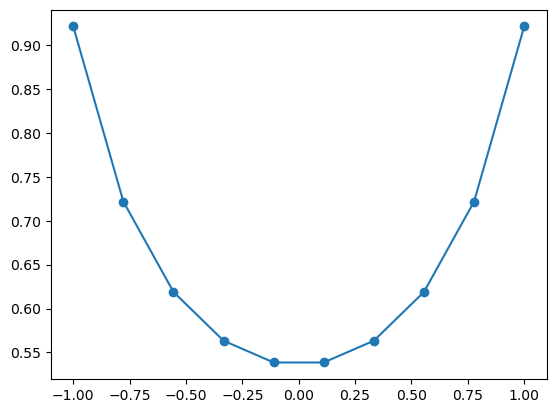

In [28]:
analyze_and_draw(uniform_vector_n10)

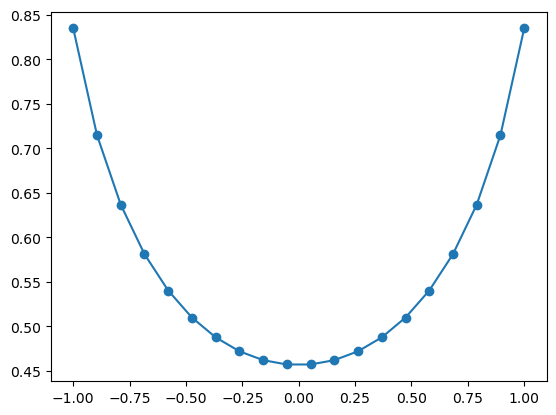

In [29]:
analyze_and_draw(uniform_vector_n20)

Porównamy wyniki dla każdego ze zbioru punktów na zbiorczym wykresie:

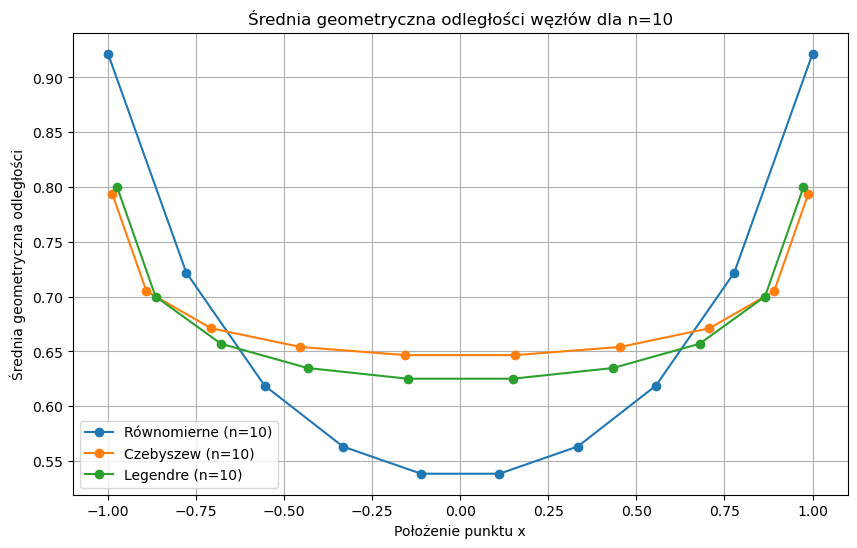

In [9]:
plt.figure(figsize=(10, 6))

n = 10

uniform_points = generate_uniform_points(n)
chebyshev_points = generate_chebyshev_points(n)
legendre_points = generate_legendre_points(n)

analyze_and_draw(uniform_points, "Równomierne")
analyze_and_draw(chebyshev_points, "Czebyszew")
analyze_and_draw(legendre_points, "Legendre")

plt.title(f"Średnia geometryczna odległości węzłów dla n={n}")
plt.xlabel("Położenie punktu x")
plt.ylabel("Średnia geometryczna odległości")
plt.legend() 
plt.grid(True) 
plt.show() 

### Zadanie 2 - wielomiany interpolujące funkcje

Zaczynamy od interpolacji funkcji f_1, a zatem słynnej funkcji Rungego - przypadku trudnego do zinterpolowania:

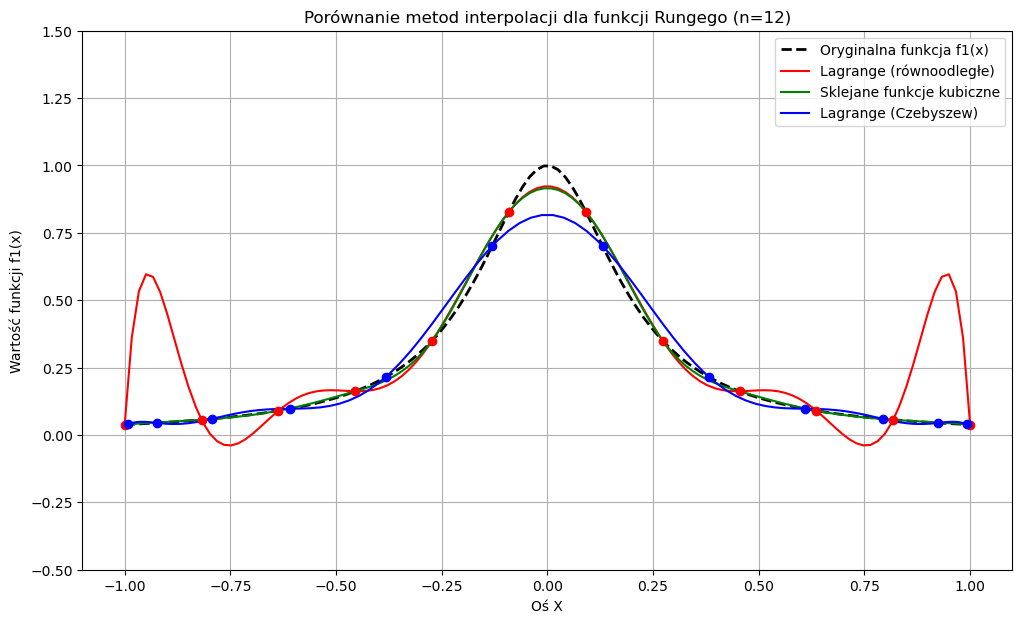

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BarycentricInterpolator, CubicSpline

# definicja funkcji f_1
def f1(x):
    return 1 / (1 + 25 * x**2)

n = 12
n_dense = n * 10 

# węzły równoodległe
x_eq = np.linspace(-1, 1, n)
y_eq = f1(x_eq)

# węzły Czebyszewa
j = np.arange(1, n + 1)
theta = (2 * j - 1) / (2 * n) * np.pi
x_cheb = np.cos(theta)
x_cheb = np.sort(x_cheb) 
y_cheb = f1(x_cheb)

x_dense_eq = np.linspace(-1, 1, n_dense)

theta_dense = np.linspace(0, np.pi, n_dense)
x_dense_cheb = np.sort(np.cos(theta_dense))

model_lagrange_eq = BarycentricInterpolator(x_eq, y_eq)
y_dense_lagrange_eq = model_lagrange_eq(x_dense_eq)

model_spline = CubicSpline(x_eq, y_eq)
y_dense_spline = model_spline(x_dense_eq)

model_lagrange_cheb = BarycentricInterpolator(x_cheb, y_cheb)
y_dense_lagrange_cheb = model_lagrange_cheb(x_dense_cheb)

# prawdziwe wartości funkcji f1 (dla porównania)
y_prawdziwe = f1(x_dense_eq)

plt.figure(figsize=(12, 7))

plt.plot(x_dense_eq, y_prawdziwe, 'k--', linewidth=2, label='Oryginalna funkcja f1(x)')

plt.plot(x_dense_eq, y_dense_lagrange_eq, label='Lagrange (równoodległe)', color='red')
plt.plot(x_dense_eq, y_dense_spline, label='Sklejane funkcje kubiczne', color='green')
plt.plot(x_dense_cheb, y_dense_lagrange_cheb, label='Lagrange (Czebyszew)', color='blue')

plt.scatter(x_eq, y_eq, color='red', zorder=5) 
plt.scatter(x_cheb, y_cheb, color='blue', zorder=5) 

plt.title(f"Porównanie metod interpolacji dla funkcji Rungego (n={n})")
plt.xlabel("Oś X")
plt.ylabel("Wartość funkcji f1(x)")
plt.ylim(-0.5, 1.5) 
plt.legend()
plt.grid(True)
plt.show()

Teraz pora na funkcję f_2. Należy pamiętać o przeskalowaniu przedziału próbkowania z [-1, 1] do [0, 2pi]:

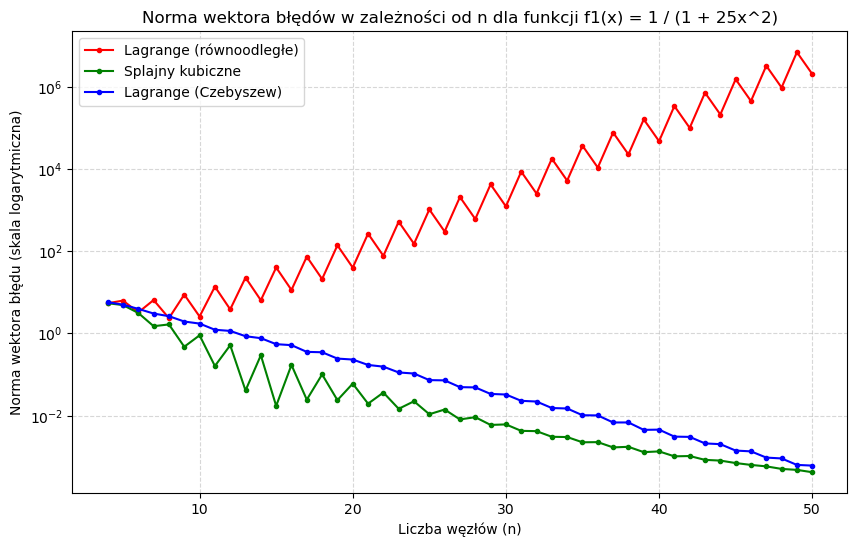

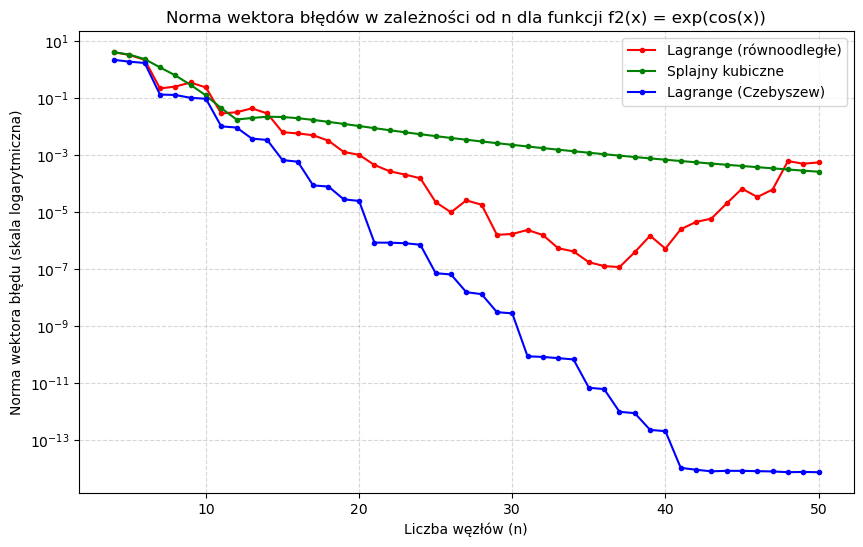

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BarycentricInterpolator, CubicSpline

def f1(x):
    return 1 / (1 + 25 * x**2)

def f2(x):
    return np.exp(np.cos(x))

def analyze_and_plot_errors(func, a, b, func_name):
    """
    Evaluates interpolation models for n from 4 to 50, calculates the error 
    norm on 500 random points, and plots the results.
    a, b - start and end of the interval (domain)
    """
    nodes_n = np.arange(4, 51) 
    
    errors_lagrange_eq = []
    errors_spline = []
    errors_lagrange_cheb = []
    
    x_test = np.random.uniform(a, b, 500)
    y_test_true = func(x_test)
    
    for n in nodes_n:
        x_eq = np.linspace(a, b, n)
        y_eq = func(x_eq)
        
        j = np.arange(1, n + 1)
        theta = (2 * j - 1) / (2 * n) * np.pi
        x_cheb_base = np.cos(theta)
        x_cheb = 0.5 * (a + b) + 0.5 * (b - a) * x_cheb_base 
        x_cheb = np.sort(x_cheb)
        y_cheb = func(x_cheb)
        
        model_lagrange_eq = BarycentricInterpolator(x_eq, y_eq)
        model_spline = CubicSpline(x_eq, y_eq)
        model_lagrange_cheb = BarycentricInterpolator(x_cheb, y_cheb)
        
        y_pred_lagrange_eq = model_lagrange_eq(x_test)
        y_pred_spline = model_spline(x_test)
        y_pred_lagrange_cheb = model_lagrange_cheb(x_test)
        
        err_lagr_eq = np.linalg.norm(y_test_true - y_pred_lagrange_eq)
        err_spline = np.linalg.norm(y_test_true - y_pred_spline)
        err_lagr_cheb = np.linalg.norm(y_test_true - y_pred_lagrange_cheb)
        
        errors_lagrange_eq.append(err_lagr_eq)
        errors_spline.append(err_spline)
        errors_lagrange_cheb.append(err_lagr_cheb)
        
    plt.figure(figsize=(10, 6))
    plt.plot(nodes_n, errors_lagrange_eq, label='Lagrange (equidistant)', color='red', marker='.')
    plt.plot(nodes_n, errors_spline, label='Cubic Splines', color='green', marker='.')
    plt.plot(nodes_n, errors_lagrange_cheb, label='Lagrange (Chebyshev)', color='blue', marker='.')
    
    plt.title(f"Error vector norm vs. n for {func_name}")
    plt.xlabel("Number of nodes (n)")
    plt.ylabel("Error vector norm (log scale)")
    
    plt.yscale('log') 
    
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()

analyze_and_plot_errors(f1, -1, 1, "f1(x) = 1 / (1 + 25x^2)")

analyze_and_plot_errors(f2, 0, 2*np.pi, "f2(x) = exp(cos(x))")